<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/emissions/Hydrocarbon_emissions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Emissions from oil and gas production operations

The currently applied technology for producing oil and gas from various
installations results in three main types of gas emissions:

- combustion gases consisting of carbon dioxide and minor amounts of carbon
  monoxide, nitrous oxide, N2O, SO2, and un-combusted hydrocarbons (methane and
  volatile organic compounds, VOCs);
- hydrocarbons consisting of methane and primarily aliphatic VOCs vented to the
  atmosphere or escaping from hydrocarbon processes through fugitive emissions;
  and
- releases of halon and other chlorofluorocarbon gases from fire-fighting and
  refrigeration systems.

**Audience.** Process, environmental, production, and facilities engineers who
need a thermodynamic estimate of flash-gas emissions from produced-water
depressurization.

**Prerequisites.** Basic phase equilibrium, process streams, separators, valves,
and Python. No proprietary data or local files are required.

## Learning objectives

By the end, you can:

1. model water-rich fluids with dissolved hydrocarbons using NeqSim CPA;
2. connect high-pressure separation, liquid letdown, and atmospheric separation;
3. calculate methane, VOC, CO2, and water-vapor rates in a flash-gas vent;
4. close total and component balances around the connected process;
5. quantify pressure and temperature sensitivity; and
6. screen vapor recovery and flare scenarios without confusing screening with a
   regulatory emissions inventory.

[See the original PetroWiki overview of emissions from oil and gas production
operations](https://petrowiki.spe.org/Emissions_from_oil_and_gas_production_operations).

The original learning objective is preserved: calculate hydrocarbon release when
produced water is depressurized. The example below replaces the obsolete package
pin and brittle phase access with a current, guarded, end-to-end process model.

# NeqSim calculations

The calculation separates the emission mechanism from the reporting scenario.
NeqSim predicts the equilibrium flash gas. A later accounting layer applies
capture or destruction assumptions to that calculated stream.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ],
        check=True,
    )

In [2]:
import platform
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from jpype import java
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

from neqsim.process import (
    clearProcess,
    runProcess,
    separator,
    stream,
    valve,
)
from neqsim.thermo import fluid


plt.rcParams.update(
    {
        "axes.grid": True,
        "figure.dpi": 120,
        "figure.figsize": (9, 5),
        "font.size": 10,
        "grid.alpha": 0.25,
    }
)

COMPONENTS = [
    "water",
    "methane",
    "ethane",
    "propane",
    "i-butane",
    "CO2",
]
FEED_COMPOSITION = {
    "water": 0.9950,
    "methane": 0.0040,
    "ethane": 0.0005,
    "propane": 0.0002,
    "i-butane": 0.0001,
    "CO2": 0.0002,
}


def build_flash_emission_case(
    feed_pressure_bara=70.0,
    discharge_pressure_bara=1.5,
    feed_temperature_c=60.0,
    feed_rate_kg_h=100_000.0,
):
    clearProcess()

    produced_water = fluid("cpa")
    for component_name, mole_fraction in FEED_COMPOSITION.items():
        produced_water.addComponent(
            component_name,
            mole_fraction,
        )

    produced_water.setMixingRule(10)
    produced_water.setTemperature(feed_temperature_c, "C")
    produced_water.setPressure(feed_pressure_bara, "bara")

    feed_stream = stream("produced water feed", produced_water)
    feed_stream.setFlowRate(feed_rate_kg_h, "kg/hr")

    high_pressure_separator = separator(
        "high-pressure separator",
        feed_stream,
    )
    water_letdown = valve(
        "produced-water letdown",
        high_pressure_separator.getLiquidOutStream(),
    )
    water_letdown.setOutletPressure(
        discharge_pressure_bara,
        "bara",
    )
    low_pressure_separator = separator(
        "low-pressure water separator",
        water_letdown.getOutletStream(),
    )

    runProcess()

    return {
        "feed": feed_stream,
        "high_pressure_separator": high_pressure_separator,
        "valve": water_letdown,
        "low_pressure_separator": low_pressure_separator,
        "high_pressure_gas": (
            high_pressure_separator.getGasOutStream()
        ),
        "flash_gas": low_pressure_separator.getGasOutStream(),
        "treated_water": (
            low_pressure_separator.getLiquidOutStream()
        ),
    }


base_case = build_flash_emission_case()
base_emission_rate = float(
    base_case["flash_gas"].getFlowRate("kg/hr")
)
print(
    "Estimated total flash-gas rate:",
    f"{base_emission_rate:.3f} kg/h",
)

Estimated total flash-gas rate: 152.862 kg/h


## Reproducible environment and design basis

The original notebook pinned NeqSim 2.5.35. The preserved setup cell now installs
the current public-PyPI release only when needed. The base case is a synthetic
produced-water stream at 70 bara and 60 °C, flowing at 100,000 kg/h, with 0.5
mol% dissolved gases. It first flashes at production pressure, then the liquid is
throttled to 1.5 bara and separated again.

The high-pressure gas is assumed routed back to the hydrocarbon process. Only the
low-pressure flash gas is counted as a potential atmospheric emission.

In [3]:
runtime_table = pd.Series(
    {
        "NeqSim": version("neqsim"),
        "Python": platform.python_version(),
        "Java": str(java.lang.System.getProperty("java.version")),
    },
    name="Version",
).to_frame()

design_basis_table = pd.Series(
    {
        "Feed mass flow [kg/h]": 100_000.0,
        "Feed temperature [°C]": 60.0,
        "Feed pressure [bara]": 70.0,
        "Discharge pressure [bara]": 1.5,
        "Thermodynamic model": "CPA",
        "Mixing rule": "CPA rule 10",
    },
    name="Design basis",
).to_frame()

display(runtime_table)
display(design_basis_table)

,Version
NeqSim,3.16.0
Python,3.12.13
Java,17.0.19


,Design basis
Feed mass flow [kg/h],100000.0
Feed temperature [°C],60.0
Feed pressure [bara],70.0
Discharge pressure [bara],1.5
Thermodynamic model,CPA
Mixing rule,CPA rule 10


## Thermodynamic mechanism

Dissolved gas is retained in the aqueous phase at high pressure. A valve reduces
pressure approximately isenthalpically:

$$
h_{in} = h_{out}
$$

Here $h$ is specific enthalpy in J/kg. The downstream separator establishes
vapor-liquid equilibrium. For component $i$:

$$
f_i^V(T,P,\mathbf{y}) = f_i^L(T,P,\mathbf{x})
$$

The fugacities $f_i^V$ and $f_i^L$ are in Pa; $T$ is temperature in K, $P$ is
pressure in Pa, and $\mathbf{y}$ and $\mathbf{x}$ are vapor and liquid
compositions. CPA is selected because its association term represents the strong
hydrogen bonding of water while retaining a cubic-EOS treatment of hydrocarbons.

In [4]:
composition_table = pd.DataFrame(
    {
        "Component": list(FEED_COMPOSITION),
        "Feed mole fraction [-]": list(
            FEED_COMPOSITION.values()
        ),
    }
)
assert np.isclose(
    composition_table["Feed mole fraction [-]"].sum(),
    1.0,
)
composition_table

Out[4]: 
  Component  Feed mole fraction [-]
0     water                  0.9950
1   methane                  0.0040
2    ethane                  0.0005
3   propane                  0.0002
4  i-butane                  0.0001
5       CO2                  0.0002


## Connected process and calculation sequence

`Stream` holds the CPA fluid state. The high-pressure `Separator` removes any
free gas before water handling. `ThrottlingValve` applies the pressure boundary,
and the low-pressure `Separator` publishes flash-gas and treated-water streams.
`runProcess` executes the connected objects in dependency order.

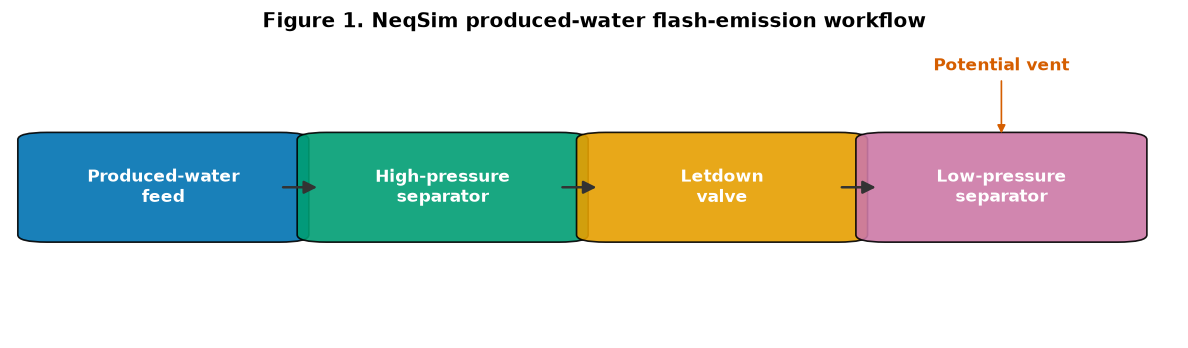

In [5]:
process_nodes = [
    ("Produced-water\nfeed", 0.03, "#0072B2"),
    ("High-pressure\nseparator", 0.27, "#009E73"),
    ("Letdown\nvalve", 0.51, "#E69F00"),
    ("Low-pressure\nseparator", 0.75, "#CC79A7"),
]

figure, axis = plt.subplots(figsize=(10, 3.0))
axis.set_xlim(0.0, 1.0)
axis.set_ylim(0.0, 1.0)
axis.axis("off")

for label, left, color in process_nodes:
    box = FancyBboxPatch(
        (left, 0.35),
        0.20,
        0.33,
        boxstyle="round,pad=0.025",
        facecolor=color,
        edgecolor="black",
        linewidth=1.0,
        alpha=0.9,
    )
    axis.add_patch(box)
    axis.text(
        left + 0.10,
        0.515,
        label,
        color="white",
        ha="center",
        va="center",
        weight="bold",
    )

for left in [0.23, 0.47, 0.71]:
    arrow = FancyArrowPatch(
        (left, 0.515),
        (left + 0.035, 0.515),
        arrowstyle="-|>",
        mutation_scale=16,
        color="#333333",
        linewidth=1.5,
    )
    axis.add_patch(arrow)

axis.annotate(
    "Potential vent",
    xy=(0.85, 0.69),
    xytext=(0.85, 0.92),
    ha="center",
    arrowprops={
        "arrowstyle": "-|>",
        "color": "#D55E00",
    },
    color="#D55E00",
    weight="bold",
)
axis.set_title(
    "Figure 1. NeqSim produced-water flash-emission workflow",
    pad=12,
    weight="bold",
)
figure.tight_layout()
plt.show()

## Stream diagnostics

The high-pressure separator gas is a process stream, not automatically an
emission. The low-pressure flash gas becomes an emission only if it is vented.
Reporting the streams separately prevents double counting.

In [6]:
def summarize_stream(process_stream, label):
    return {
        "Stream": label,
        "Mass flow [kg/h]": float(
            process_stream.getFlowRate("kg/hr")
        ),
        "Temperature [°C]": float(
            process_stream.getTemperature("C")
        ),
        "Pressure [bara]": float(
            process_stream.getPressure("bara")
        ),
        "Volumetric flow [m³/h]": float(
            process_stream.getFlowRate("m3/hr")
        ),
    }


base_stream_table = pd.DataFrame(
    [
        summarize_stream(base_case["feed"], "Feed"),
        summarize_stream(
            base_case["high_pressure_gas"],
            "High-pressure process gas",
        ),
        summarize_stream(
            base_case["flash_gas"],
            "Low-pressure flash gas",
        ),
        summarize_stream(
            base_case["treated_water"],
            "Treated water",
        ),
    ]
)
base_stream_table

Out[6]: 
                      Stream  ...  Volumetric flow [m³/h]
0                       Feed  ...              108.516201
1  High-pressure process gas  ...                7.452886
2     Low-pressure flash gas  ...              133.952518
3              Treated water  ...              101.097708

[4 rows x 5 columns]


## Emission-species accounting

NeqSim stores component molar rates in mol/s. Component mass rate is calculated
as:

$$
\dot{m}_i = \dot{n}_i M_i
$$

Here $\dot{m}_i$ is kg/s, $\dot{n}_i$ is mol/s, and $M_i$ is kg/mol. Results are
converted to kg/h. Methane is reported separately from VOCs; CO2 and water vapor
are not classified as hydrocarbon emissions.

In [7]:
def component_mass_rates(process_stream):
    stream_fluid = process_stream.getFluid()
    return {
        component_name: float(
            stream_fluid.getComponent(
                component_name
            ).getNumberOfmoles()
            * stream_fluid.getComponent(
                component_name
            ).getMolarMass()
            * 3600.0
        )
        for component_name in COMPONENTS
    }


flash_component_rates = component_mass_rates(
    base_case["flash_gas"]
)
emission_component_table = pd.DataFrame(
    {
        "Component": list(flash_component_rates),
        "Flash-gas rate [kg/h]": list(
            flash_component_rates.values()
        ),
    }
)
emission_component_table["Classification"] = [
    "Water vapor",
    "Methane",
    "VOC",
    "VOC",
    "VOC",
    "Carbon dioxide",
]

methane_rate_kg_h = flash_component_rates["methane"]
voc_rate_kg_h = sum(
    flash_component_rates[component_name]
    for component_name in [
        "ethane",
        "propane",
        "i-butane",
    ]
)
hydrocarbon_rate_kg_h = methane_rate_kg_h + voc_rate_kg_h

display(emission_component_table)
pd.Series(
    {
        "Methane [kg/h]": methane_rate_kg_h,
        "VOC [kg/h]": voc_rate_kg_h,
        "Total hydrocarbon [kg/h]": hydrocarbon_rate_kg_h,
    },
    name="Potential vent",
).to_frame()

Out[7]: 
                          Potential vent
Methane [kg/h]                 74.832243
VOC [kg/h]                     29.992555
Total hydrocarbon [kg/h]      104.824798


,Component,Flash-gas rate [kg/h],Classification
0,water,18.384784,Water vapor
1,methane,74.832243,Methane
2,ethane,22.530536,VOC
3,propane,4.473524,VOC
4,i-butane,2.988495,VOC
5,CO2,29.652113,Carbon dioxide


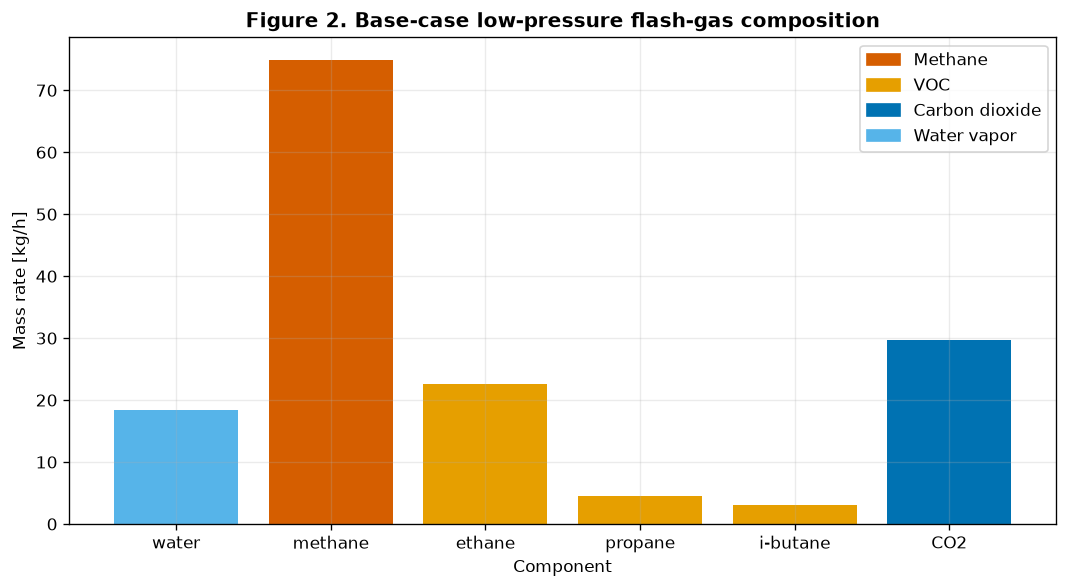

In [8]:
figure, axis = plt.subplots(figsize=(9, 5))
classification_colors = {
    "Methane": "#D55E00",
    "VOC": "#E69F00",
    "Carbon dioxide": "#0072B2",
    "Water vapor": "#56B4E9",
}
bar_colors = [
    classification_colors[classification]
    for classification in emission_component_table[
        "Classification"
    ]
]

axis.bar(
    emission_component_table["Component"],
    emission_component_table["Flash-gas rate [kg/h]"],
    color=bar_colors,
)
axis.set_title(
    "Figure 2. Base-case low-pressure flash-gas composition",
    weight="bold",
)
axis.set_xlabel("Component")
axis.set_ylabel("Mass rate [kg/h]")

legend_handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=color,
        label=classification,
    )
    for classification, color in classification_colors.items()
]
axis.legend(handles=legend_handles)
figure.tight_layout()
plt.show()

Methane is the largest hydrocarbon contribution in this synthetic case. Water
vapor and CO2 remain visible because they contribute to total vent mass and may
matter for downstream recovery or flare calculations, but they are not included
in the hydrocarbon subtotal.

## Total and component material balance

The process boundary includes high-pressure process gas, low-pressure flash gas,
and treated water. Component closure is evaluated for every modeled species.

In [9]:
product_streams = [
    base_case["high_pressure_gas"],
    base_case["flash_gas"],
    base_case["treated_water"],
]
feed_mass_kg_h = float(
    base_case["feed"].getFlowRate("kg/hr")
)
product_mass_kg_h = sum(
    float(product_stream.getFlowRate("kg/hr"))
    for product_stream in product_streams
)
normalized_mass_residual = abs(
    feed_mass_kg_h - product_mass_kg_h
) / feed_mass_kg_h

feed_component_rates = component_mass_rates(base_case["feed"])
product_component_rates = {
    component_name: sum(
        component_mass_rates(product_stream)[component_name]
        for product_stream in product_streams
    )
    for component_name in COMPONENTS
}

component_balance_table = pd.DataFrame(
    {
        "Component": COMPONENTS,
        "Feed [kg/h]": [
            feed_component_rates[name]
            for name in COMPONENTS
        ],
        "Products [kg/h]": [
            product_component_rates[name]
            for name in COMPONENTS
        ],
    }
)
component_balance_table["Normalized residual [-]"] = (
    np.abs(
        component_balance_table["Feed [kg/h]"]
        - component_balance_table["Products [kg/h]"]
    )
    / np.maximum(
        component_balance_table["Feed [kg/h]"],
        1.0e-15,
    )
)

display(
    pd.Series(
        {
            "Total mass residual [-]": (
                normalized_mass_residual
            ),
            "Maximum component residual [-]": (
                component_balance_table[
                    "Normalized residual [-]"
                ].max()
            ),
        },
        name="Closure",
    ).to_frame()
)
component_balance_table

Out[9]: 
  Component   Feed [kg/h]  Products [kg/h]  Normalized residual [-]
0     water  99430.645814     99430.645814             0.000000e+00
1   methane    355.965975       355.965975             3.832507e-15
2    ethane     83.400057        83.400057             1.175717e-14
3   propane     48.921747        48.921747             1.249070e-14
4  i-butane     32.241181        32.241181             1.256187e-14
5       CO2     48.825228        48.825228             6.214037e-14


,Closure
Total mass residual [-],2.910383e-16
Maximum component residual [-],6.214037e-14


## Pressure sensitivity

A higher water-disposal or treatment pressure suppresses flashing. The study
changes only the low-pressure separator pressure from 1.2 to 6 bara, keeping feed
composition, flow, temperature, and upstream separation fixed.

In [10]:
discharge_pressures_bara = np.array(
    [1.2, 1.5, 2.0, 3.0, 4.5, 6.0]
)
pressure_records = []

for discharge_pressure_bara in discharge_pressures_bara:
    pressure_case = build_flash_emission_case(
        discharge_pressure_bara=discharge_pressure_bara
    )
    component_rates = component_mass_rates(
        pressure_case["flash_gas"]
    )
    pressure_records.append(
        {
            "Discharge pressure [bara]": (
                discharge_pressure_bara
            ),
            "Total flash gas [kg/h]": float(
                pressure_case["flash_gas"].getFlowRate("kg/hr")
            ),
            "Methane [kg/h]": component_rates["methane"],
            "VOC [kg/h]": sum(
                component_rates[name]
                for name in [
                    "ethane",
                    "propane",
                    "i-butane",
                ]
            ),
        }
    )

pressure_sensitivity_table = pd.DataFrame(pressure_records)
pressure_sensitivity_table

Out[10]: 
   Discharge pressure [bara]  ...  VOC [kg/h]
0                        1.2  ...   30.215186
1                        1.5  ...   29.992555
2                        2.0  ...   29.622080
3                        3.0  ...   28.886995
4                        4.5  ...   27.808027
5                        6.0  ...   26.764559

[6 rows x 4 columns]


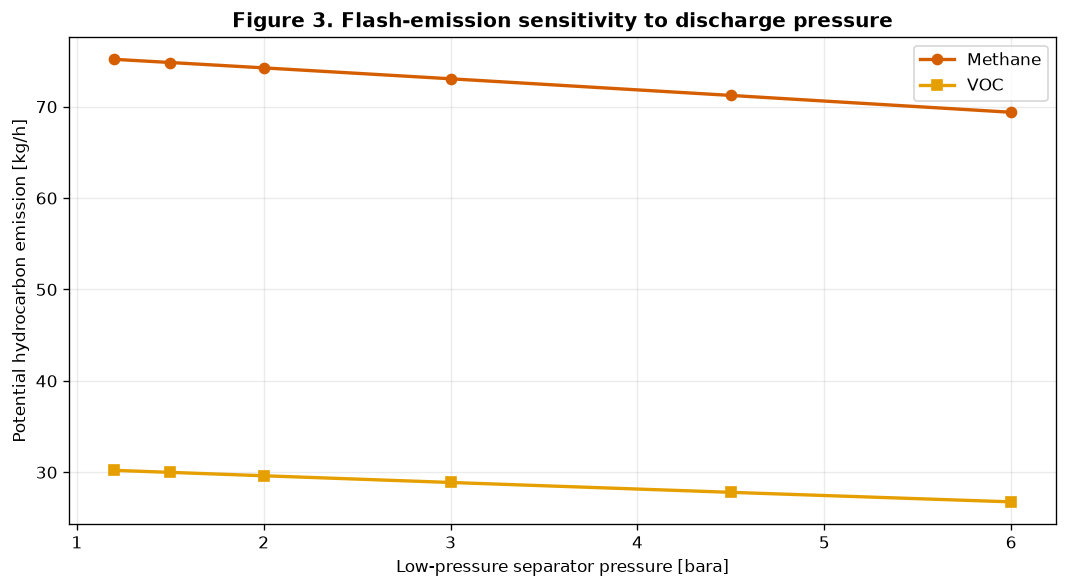

In [11]:
figure, axis = plt.subplots(figsize=(9, 5))

axis.plot(
    pressure_sensitivity_table["Discharge pressure [bara]"],
    pressure_sensitivity_table["Methane [kg/h]"],
    marker="o",
    linewidth=2.0,
    color="#D55E00",
    label="Methane",
)
axis.plot(
    pressure_sensitivity_table["Discharge pressure [bara]"],
    pressure_sensitivity_table["VOC [kg/h]"],
    marker="s",
    linewidth=2.0,
    color="#E69F00",
    label="VOC",
)
axis.set_title(
    "Figure 3. Flash-emission sensitivity to discharge pressure",
    weight="bold",
)
axis.set_xlabel("Low-pressure separator pressure [bara]")
axis.set_ylabel("Potential hydrocarbon emission [kg/h]")
axis.legend()
figure.tight_layout()
plt.show()

The calculated hydrocarbon release decreases as discharge pressure increases.
This is a thermodynamic inventory result, not a recommendation to raise disposal
pressure without checking water-treatment performance, pump duty, equipment
design pressure, and operating constraints.

## Combined temperature-pressure operating map

Feed temperature affects gas solubility and the enthalpy available during
letdown. A compact grid reveals where pressure and temperature assumptions most
strongly influence the methane estimate.

In [12]:
feed_temperatures_c = np.array([30.0, 45.0, 60.0, 75.0])
map_pressures_bara = np.array([1.5, 2.5, 4.0, 6.0])
methane_map = np.zeros(
    (
        len(feed_temperatures_c),
        len(map_pressures_bara),
    )
)

for temperature_index, feed_temperature_c in enumerate(
    feed_temperatures_c
):
    for pressure_index, discharge_pressure_bara in enumerate(
        map_pressures_bara
    ):
        map_case = build_flash_emission_case(
            feed_temperature_c=feed_temperature_c,
            discharge_pressure_bara=discharge_pressure_bara,
        )
        map_rates = component_mass_rates(
            map_case["flash_gas"]
        )
        methane_map[
            temperature_index,
            pressure_index,
        ] = map_rates["methane"]

pd.DataFrame(
    methane_map,
    index=[
        f"{temperature_c:.0f} °C"
        for temperature_c in feed_temperatures_c
    ],
    columns=[
        f"{pressure_bara:.1f} bara"
        for pressure_bara in map_pressures_bara
    ],
)

Out[12]: 
        1.5 bara   2.5 bara   4.0 bara   6.0 bara
30 °C  99.746299  97.997576  95.339875  91.774426
45 °C  84.743507  83.337644  81.191384  78.296845
60 °C  74.832243  73.651243  71.840974  69.387455
75 °C  68.366325  67.336699  65.751587  63.592819


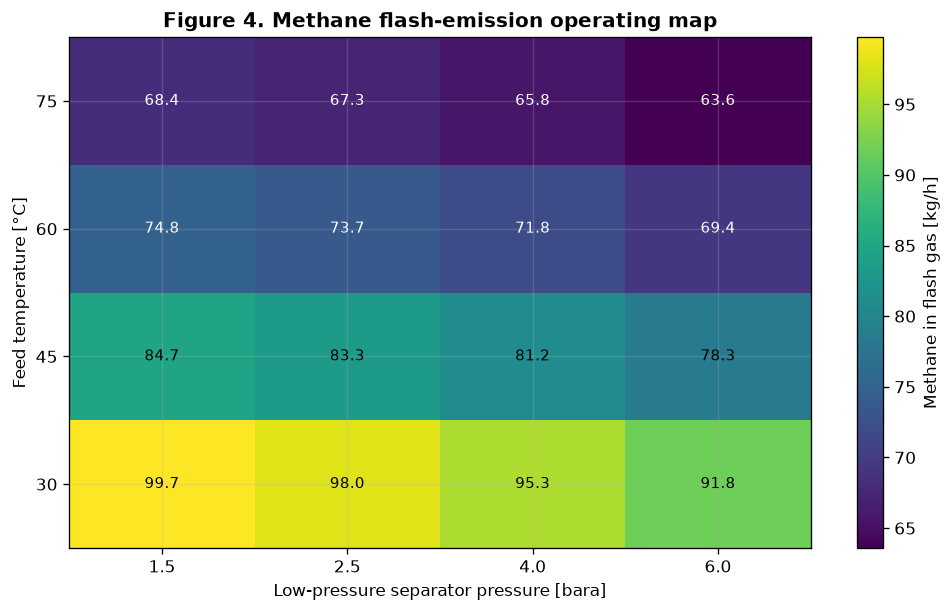

In [13]:
figure, axis = plt.subplots(figsize=(8.5, 5.2))
image = axis.imshow(
    methane_map,
    aspect="auto",
    origin="lower",
    cmap="viridis",
)
axis.set_xticks(
    np.arange(len(map_pressures_bara)),
    labels=[
        f"{pressure:.1f}"
        for pressure in map_pressures_bara
    ],
)
axis.set_yticks(
    np.arange(len(feed_temperatures_c)),
    labels=[
        f"{temperature:.0f}"
        for temperature in feed_temperatures_c
    ],
)
axis.set_xlabel("Low-pressure separator pressure [bara]")
axis.set_ylabel("Feed temperature [°C]")
axis.set_title(
    "Figure 4. Methane flash-emission operating map",
    weight="bold",
)

for row_index in range(methane_map.shape[0]):
    for column_index in range(methane_map.shape[1]):
        axis.text(
            column_index,
            row_index,
            f"{methane_map[row_index, column_index]:.1f}",
            ha="center",
            va="center",
            color=(
                "white"
                if methane_map[row_index, column_index]
                < np.nanmedian(methane_map)
                else "black"
            ),
            fontsize=9,
        )

colorbar = figure.colorbar(image, ax=axis)
colorbar.set_label("Methane in flash gas [kg/h]")
figure.tight_layout()
plt.show()

The operating map is useful for bounding seasonal and process-condition
uncertainty. It should be regenerated with measured water composition and
representative separator temperatures before use in an emissions estimate.

## Mitigation screening

Thermodynamics determines the inlet to a mitigation system. Simple availability
and performance factors then estimate atmospheric release:

$$
\dot{m}_{released} =
\dot{m}_{flash}
\left[
(1-A) + A(1-\eta)
\right]
$$

Here $\dot{m}_{flash}$ and $\dot{m}_{released}$ are kg/h, $A$ is system
availability, and $\eta$ is capture or destruction efficiency. The factors are
synthetic screening inputs; use verified equipment performance and reporting
rules for inventories.

In [14]:
mitigation_scenarios = pd.DataFrame(
    [
        {
            "Scenario": "Open vent",
            "Availability [-]": 1.00,
            "Removal efficiency [-]": 0.00,
        },
        {
            "Scenario": "Vapor recovery unit",
            "Availability [-]": 0.95,
            "Removal efficiency [-]": 0.95,
        },
        {
            "Scenario": "Enclosed flare",
            "Availability [-]": 0.98,
            "Removal efficiency [-]": 0.98,
        },
    ]
)

release_factor = (
    1.0
    - mitigation_scenarios["Availability [-]"]
    * mitigation_scenarios["Removal efficiency [-]"]
)
mitigation_scenarios["Released methane [kg/h]"] = (
    methane_rate_kg_h * release_factor
)
mitigation_scenarios["Released VOC [kg/h]"] = (
    voc_rate_kg_h * release_factor
)
mitigation_scenarios["Removed hydrocarbon [kg/h]"] = (
    hydrocarbon_rate_kg_h
    - mitigation_scenarios["Released methane [kg/h]"]
    - mitigation_scenarios["Released VOC [kg/h]"]
)
mitigation_scenarios

Out[14]: 
              Scenario  ...  Removed hydrocarbon [kg/h]
0            Open vent  ...                    0.000000
1  Vapor recovery unit  ...                   94.604380
2       Enclosed flare  ...                  100.673736

[3 rows x 6 columns]


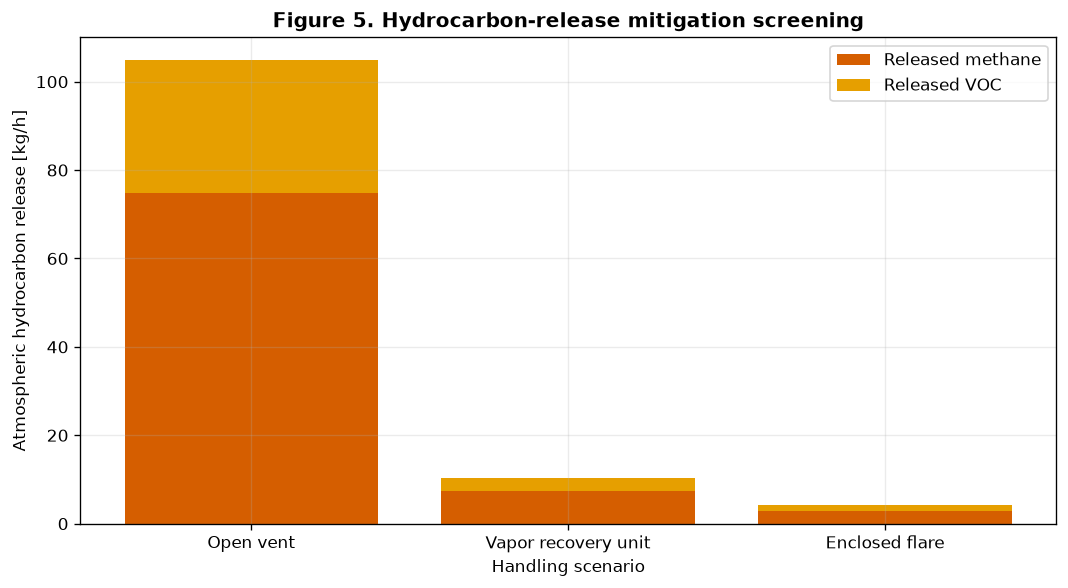

In [15]:
figure, axis = plt.subplots(figsize=(9, 5))

axis.bar(
    mitigation_scenarios["Scenario"],
    mitigation_scenarios["Released methane [kg/h]"],
    color="#D55E00",
    label="Released methane",
)
axis.bar(
    mitigation_scenarios["Scenario"],
    mitigation_scenarios["Released VOC [kg/h]"],
    bottom=mitigation_scenarios["Released methane [kg/h]"],
    color="#E69F00",
    label="Released VOC",
)
axis.set_title(
    "Figure 5. Hydrocarbon-release mitigation screening",
    weight="bold",
)
axis.set_xlabel("Handling scenario")
axis.set_ylabel("Atmospheric hydrocarbon release [kg/h]")
axis.legend()
figure.tight_layout()
plt.show()

Vapor recovery preserves product and avoids combustion. A flare can reduce
hydrocarbon release but creates combustion products and requires separate flare
capacity, availability, pilot, and destruction-efficiency evaluation. Neither
scenario replaces a measurement and source-classification program.

## Final application: reusable emissions-screening workflow

The function below combines the NeqSim process model, component retrieval,
closure calculation, and mitigation accounting. Engineers can replace the
synthetic composition, rates, and scenario assumptions while keeping the same
validation pattern.

In [16]:
def run_emissions_screen(
    feed_temperature_c,
    discharge_pressure_bara,
    availability,
    removal_efficiency,
):
    process_case = build_flash_emission_case(
        feed_temperature_c=feed_temperature_c,
        discharge_pressure_bara=discharge_pressure_bara,
    )
    flash_rates = component_mass_rates(
        process_case["flash_gas"]
    )
    methane_kg_h = flash_rates["methane"]
    voc_kg_h = sum(
        flash_rates[name]
        for name in ["ethane", "propane", "i-butane"]
    )
    remaining_fraction = (
        1.0 - availability * removal_efficiency
    )

    process_products = [
        process_case["high_pressure_gas"],
        process_case["flash_gas"],
        process_case["treated_water"],
    ]
    process_feed_kg_h = float(
        process_case["feed"].getFlowRate("kg/hr")
    )
    process_products_kg_h = sum(
        float(product.getFlowRate("kg/hr"))
        for product in process_products
    )

    return pd.Series(
        {
            "Feed temperature [°C]": feed_temperature_c,
            "Discharge pressure [bara]": (
                discharge_pressure_bara
            ),
            "Potential methane [kg/h]": methane_kg_h,
            "Potential VOC [kg/h]": voc_kg_h,
            "Released methane [kg/h]": (
                methane_kg_h * remaining_fraction
            ),
            "Released VOC [kg/h]": (
                voc_kg_h * remaining_fraction
            ),
            "Mass balance residual [-]": abs(
                process_feed_kg_h - process_products_kg_h
            )
            / process_feed_kg_h,
        },
        name="Screening result",
    )


practical_case = run_emissions_screen(
    feed_temperature_c=45.0,
    discharge_pressure_bara=2.5,
    availability=0.95,
    removal_efficiency=0.95,
)
practical_case.to_frame()

Out[16]: 
                           Screening result
Feed temperature [°C]          4.500000e+01
Discharge pressure [bara]      2.500000e+00
Potential methane [kg/h]       8.333764e+01
Potential VOC [kg/h]           2.882321e+01
Released methane [kg/h]        8.125420e+00
Released VOC [kg/h]            2.810263e+00
Mass balance residual [-]      1.353328e-14


## Engineering acceptance checks

The checks verify API execution, finite positive streams, external total and
component closure, expected phase-split behavior, pressure response, operating
map consistency, and mitigation arithmetic. Any failure stops publication and
should stop engineering reuse.

In [17]:
maximum_component_residual = float(
    component_balance_table["Normalized residual [-]"].max()
)
total_flash_from_components = float(
    emission_component_table["Flash-gas rate [kg/h]"].sum()
)

engineering_checks = {
    "NeqSim version is reported": bool(runtime_table.size > 0),
    "Base flash-gas flow is finite": bool(
        np.isfinite(base_emission_rate)
    ),
    "Base flash-gas flow is positive": bool(
        base_emission_rate > 0.0
    ),
    "Treated-water flow is positive": bool(
        base_case["treated_water"].getFlowRate("kg/hr") > 0.0
    ),
    "Total mass balance closes below 1e-10": bool(
        normalized_mass_residual < 1.0e-10
    ),
    "Component balances close below 1e-10": bool(
        maximum_component_residual < 1.0e-10
    ),
    "Component rates reproduce flash-gas mass": bool(
        abs(total_flash_from_components - base_emission_rate)
        < 1.0e-8
    ),
    "Methane is the largest hydrocarbon": bool(
        methane_rate_kg_h
        > emission_component_table.loc[
            emission_component_table["Classification"] == "VOC",
            "Flash-gas rate [kg/h]",
        ].max()
    ),
    "Methane rate falls as pressure rises": bool(
        np.all(
            np.diff(
                pressure_sensitivity_table["Methane [kg/h]"]
            )
            < 0.0
        )
    ),
    "VOC rate falls as pressure rises": bool(
        np.all(
            np.diff(
                pressure_sensitivity_table["VOC [kg/h]"]
            )
            < 0.0
        )
    ),
    "Operating map is finite": bool(
        np.isfinite(methane_map).all()
    ),
    "Operating map rates are positive": bool(
        (methane_map > 0.0).all()
    ),
    "Mitigation reduces methane release": bool(
        (
            mitigation_scenarios.loc[
                mitigation_scenarios["Scenario"]
                != "Open vent",
                "Released methane [kg/h]",
            ]
            < methane_rate_kg_h
        ).all()
    ),
    "Mitigation releases remain nonnegative": bool(
        (
            mitigation_scenarios[
                [
                    "Released methane [kg/h]",
                    "Released VOC [kg/h]",
                ]
            ]
            >= 0.0
        ).all().all()
    ),
    "Practical case mass balance closes": bool(
        practical_case["Mass balance residual [-]"]
        < 1.0e-10
    ),
    "Practical released methane is below potential": bool(
        practical_case["Released methane [kg/h]"]
        < practical_case["Potential methane [kg/h]"]
    ),
}

validation_table = pd.DataFrame(
    {
        "Engineering check": list(engineering_checks),
        "Passed": list(engineering_checks.values()),
    }
)

assert validation_table["Passed"].all(), validation_table.loc[
    ~validation_table["Passed"]
]
print(
    "All 16 engineering checks passed. "
    f"NeqSim version: {version('neqsim')}"
)
validation_table

All 16 engineering checks passed. NeqSim version: 3.16.0
Out[17]: 
                                Engineering check  Passed
0                      NeqSim version is reported    True
1                   Base flash-gas flow is finite    True
2                 Base flash-gas flow is positive    True
3                  Treated-water flow is positive    True
4           Total mass balance closes below 1e-10    True
5            Component balances close below 1e-10    True
6        Component rates reproduce flash-gas mass    True
7              Methane is the largest hydrocarbon    True
8            Methane rate falls as pressure rises    True
9                VOC rate falls as pressure rises    True
10                        Operating map is finite    True
11               Operating map rates are positive    True
12             Mitigation reduces methane release    True
13         Mitigation releases remain nonnegative    True
14             Practical case mass balance closes    True
15  P

## Troubleshooting

- **No low-pressure gas phase:** reduce discharge pressure, increase dissolved
  gas, or verify that the high-pressure separator liquid is connected to the
  valve.
- **Unexpectedly large emissions:** confirm whether the input composition is an
  overall wellstream or an actual produced-water sample after upstream
  separation.
- **Water dominates the vent:** include vapor-water handling in recovery design,
  but do not classify water as hydrocarbon emission.
- **Balance does not close:** include all outlet streams, especially the
  high-pressure gas that is normally returned to the process.
- **Plant result differs:** regress the CPA model against measured dissolved-gas
  and water data, and use measured separator temperatures and pressures.

## Limitations, summary, and further exercises

This notebook calculates equilibrium flash emissions from a deterministic,
synthetic produced-water composition. It does not model leaks, pneumatic
devices, tank breathing, non-equilibrium mass transfer, droplet carryover, flare
combustion chemistry, or jurisdiction-specific inventory rules. Results are
screening estimates until the fluid model and operating data are validated.

**Key conclusion:** the low-pressure boundary and feed temperature materially
affect methane and VOC flashing, while vapor recovery or destruction assumptions
belong in a separate, transparent accounting layer.

Further exercises:

1. replace the synthetic composition with sampled produced-water data;
2. compare CPA with another validated water-hydrocarbon model;
3. add a vapor-recovery compressor and calculate power;
4. quantify uncertainty with distributions for dissolved gas and temperature;
5. connect hourly rates to operating time without treating downtime as zero
   emissions by default.

## Authoritative references

- [NeqSim process simulation documentation](https://equinor.github.io/neqsim/process/)
- [NeqSim thermodynamic models](https://equinor.github.io/neqsim/thermo/)
- [NeqSim Python package on PyPI](https://pypi.org/project/neqsim/)
- [PetroWiki: emissions from oil and gas production operations](https://petrowiki.spe.org/Emissions_from_oil_and_gas_production_operations)
- [US EPA greenhouse-gas emission factors hub](https://www.epa.gov/climateleadership/ghg-emission-factors-hub)